## Sampling and population

In statistics, the **population** is a set of all elements or items that you’re interested in. Populations are often vast, which makes them inappropriate for collecting and analyzing data. That’s why statisticians usually try to make some conclusions about a population by choosing and examining a representative subset of that population.

This subset of a population is called a **sample**. Ideally, the sample should preserve the essential statistical features of the population to a satisfactory extent. That way, you’ll be able to use the sample to glean conclusions about the population.

We will learn to use the pandas function sample(size=n,replace=True) to collect a random sample of size n with replacement from a population
.



**Question 1.** Using Pandas DataFrame to read the `player_data.csv` file, store the data into a varialbe called `full_data` and populate first few rows to the screen

In [14]:
import pandas as pd

full_data = pd.read_csv("player_data.csv")
full_data.head(10)

,Name,Age,Team,Salary
0,James Harden,25,HOU,23500000
1,Chris Paul,29,LAC,23410988
2,Stephen Curry,26,GSW,23180790
3,Anthony Davis,21,NOP,22458401
4,DeAndre Jordan,26,LAC,21436271
5,Jimmy Butler,25,CHI,20644400
6,Damian Lillard,24,POR,20644400
7,Russell Westbrook,26,OKC,20068563
8,Pau Gasol,34,CHI,19754465
9,Kyrie Irving,22,CLE,19317326


In [15]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    492 non-null    object
 1   Age     492 non-null    int64 
 2   Team    492 non-null    object
 3   Salary  492 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 15.5+ KB


In [16]:
full_data.describe()

,Age,Salary
count,492.000000,4.920000e+02
mean,26.536585,4.269776e+06
std,4.193473,4.773428e+06
min,19.000000,1.440900e+04
25%,23.000000,9.810840e+05
50%,26.000000,2.349257e+06
75%,29.000000,5.696006e+06
max,38.000000,2.350000e+07


### Deterministic/Convenience sampling
One sampling methodology, which is **generally a bad idea**, is to choose players who are somehow convenient to sample.  For example, you might choose players from one team that's near your house, since it's easier to survey them.  This is called, somewhat pejoratively, *convenience sampling*.

Suppose you survey only *relatively new* players with ages less than 22.  (The more experienced players didn't bother to answer your surveys about their salaries.)

**Question 2**  Assign `convenience_sample_data` to a subset of `full_data` that contains only the rows for players under the age of 22.

In [17]:
conv_sampl1=full_data.iloc[:40,:]
conv_sampl1["Salary"].mean()

16644687.175

In [18]:
convenience_sample_data = full_data[full_data["Age"] < 22]
convenience_sample_data.shape

(44, 4)

**Question 3.** Compute and assign `convenience_age` and `convenience_salary` to the average age and average salary of your convenience sample.  Since they're computed on a sample, these are called *sample averages*.

In [19]:
convenience_age = convenience_sample_data['Age'].mean()
convenience_salary = convenience_sample_data['Salary'].mean()
print("convenience_age=", convenience_age, "; convenience_salary=", convenience_salary)


convenience_age= 20.363636363636363 ; convenience_salary= 2878411.0


**Question 4.** Compute and assign `avg_age` and `avg_salary` to the average age and average salary of your `full_data`. 

In [20]:
avg_age = full_data['Age'].mean()
avg_salary = full_data['Salary'].mean()
print("avg_age=", avg_age, "; avg_salary=", avg_salary)

avg_age= 26.536585365853657 ; avg_salary= 4269775.766260163


**Question 5.** Does the convenience sample give us an accurate picture of the age and salary of the full population of NBA players in 2014-2015?  Would you expect it to, in general?  Before you move on, write a short answer in English below.  You can refer to the statistics calculated above or perform your own analysis.

No. Expect to be different because it is the average of small non-representative group of people.

### Simple random sampling
A more principled approach is to sample uniformly at random from the players.  If we ensure that each player is selected at most once, this is a *simple random sample without replacement*, sometimes abbreviated to "simple random sample" or "SRSWOR".  Imagine writing down each player's name on a card, putting the cards in an urn, and shuffling the urn.  Then, pull out cards one by one and set them aside, stopping when the specified *sample size* is reached.


**Question 6.** Produce a simple random sample of size 44 from `full_data`. Compute the sample averages (salary and age) again.  Are your results similar to `full_data` age and salary averages?  Run your code several times to get new samples.  How much do things change across samples?

In [25]:
sample_44 = full_data.sample(44, replace=False)
print(sample_44.shape)
sample_44.head()

(44, 4)


,Name,Age,Team,Salary
244,Quincy Acy,24,NYK,2397840
10,LeBron James,30,CLE,18995624
273,Glen Davis,29,LAC,1962103
256,Joel Freeland,27,POR,2106720
380,A.J. Price,28,TOT,948163


In [26]:
avg_age_sample_44 = sample_44['Age'].mean()
avg_salary_sample_44 = sample_44['Salary'].mean()
print("avg_age_sample_44=", avg_age_sample_44, "; avg_salary_sample_44=", avg_salary_sample_44)

avg_age_sample_44= 27.0 ; avg_salary_sample_44= 4263002.931818182


**Question 7** As in the previous question, analyze several simple random samples of size 100 from `full_data`.  Do the average and histogram statistics seem to change more or less across samples of this size than across samples of size 44?  And are the sample averages and histograms closer to their true values (`full_data` averages) for age or for salary?  What did you expect to see?

In [27]:
sample_100 = full_data.sample(100, replace=False)
sample_100.head()

,Name,Age,Team,Salary
358,JaMychal Green,24,TOT,1063384
197,Thabo Sefolosha,30,ATL,3283320
419,Elliot Williams,25,TOT,816482
349,Nik Stauskas,21,SAC,1109760
164,Jodie Meeks,27,DET,4150000


In [28]:
avg_age_sample_100 = sample_100['Age'].mean()
avg_salary_sample_100 = sample_100['Salary'].mean()
print("avg_age_sample_100=", avg_age_sample_100, "; avg_salary_sample_100=", avg_salary_sample_100)

avg_age_sample_100= 26.79 ; avg_salary_sample_100= 4925306.14


In [29]:
repetitions = 10000

age_avgs_list = []
salary_avgs_list = []
for i in range(1, repetitions+1):
    sample_100 = full_data.sample(200, replace=False)
    avg_age_sample_100 = sample_100['Age'].mean()
    avg_salary_sample_100 = sample_100['Salary'].mean()
    
    age_avgs_list.append(avg_age_sample_100)
    salary_avgs_list.append(avg_salary_sample_100)
    

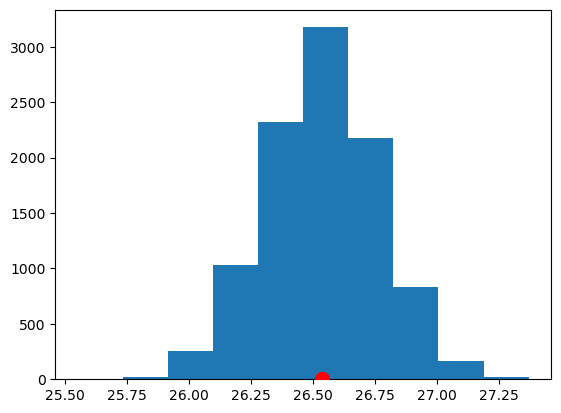

In [30]:
import matplotlib.pyplot as plt

plt.hist(age_avgs_list)
full_data_age_avg = avg_age
plt.scatter(full_data_age_avg, 0, color='red',s=100,zorder=3)

plt.show()

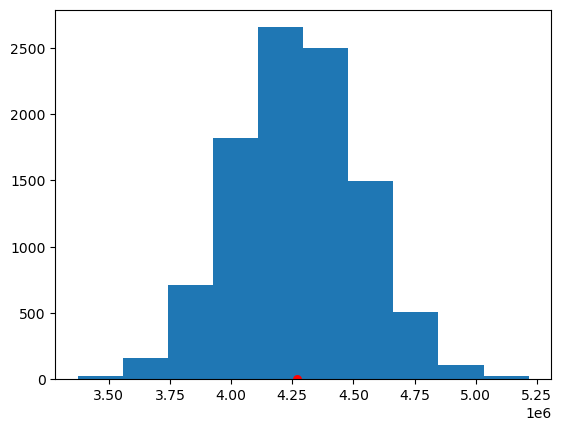

In [31]:
plt.hist(salary_avgs_list)
full_data_salary_avg = avg_salary
plt.scatter(full_data_salary_avg, 0, color='red', s=30, zorder=2)

plt.show()

**Question 8.** Repeat process in **Question 6** and **Question 7** using sample with replacement technique, then analyze any difference from prior results

In [32]:
sample_44 = full_data.sample(44, replace=True)
sample_44.head()

,Name,Age,Team,Salary
194,Ben McLemore,21,SAC,3326235
96,Marvin Williams,28,CHO,7000000
431,Paul George,24,IND,507336
98,Roy Hibbert,28,IND,7000000
193,Avery Bradley,24,BOS,3326235


In [33]:
avg_age_sample_44 = sample_44['Age'].mean()
avg_salary_sample_44 = sample_44['Salary'].mean()
print("avg_age_sample_44=", avg_age_sample_44, "; avg_salary_sample_44=", avg_salary_sample_44)

avg_age_sample_44= 26.204545454545453 ; avg_salary_sample_44= 3554084.7954545454


**Large sample size**

In [34]:
sample_100 = full_data.sample(100, replace=True)
sample_100.head()

,Name,Age,Team,Salary
234,James Ennis,24,MIA,2732000
425,Will Cherry,23,CLE,702756
175,Kentavious Caldwell-Pope,21,DET,3873398
176,Mario Chalmers,28,MIA,3867282
456,Zoran Dragic,25,TOT,379010


In [35]:
avg_age_sample_100 = sample_100['Age'].mean()
avg_salary_sample_100 = sample_100['Salary'].mean()
print("avg_age_sample_100=", avg_age_sample_100, "; avg_salary_sample_100=", avg_salary_sample_100)

avg_age_sample_100= 26.09 ; avg_salary_sample_100= 4120331.37


**Simulation**

In [36]:
repetitions = 10000

age_avgs_list = []
salary_avgs_list = []
for i in range(1, repetitions+1):
    sample_100 = full_data.sample(100, replace=True)
    avg_age_sample_100 = sample_100['Age'].mean()
    avg_salary_sample_100 = sample_100['Salary'].mean()
    
    age_avgs_list.append(avg_age_sample_100)
    salary_avgs_list.append(avg_salary_sample_100)

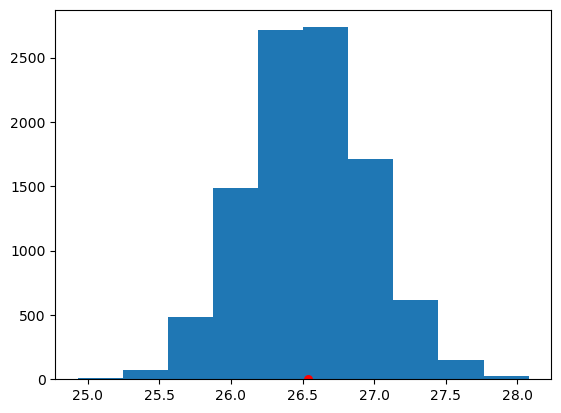

In [37]:
import matplotlib.pyplot as plt

plt.hist(age_avgs_list)
full_data_age_avg = avg_age
plt.scatter(full_data_age_avg, 0, color='red', s=30, zorder=2)

plt.show()

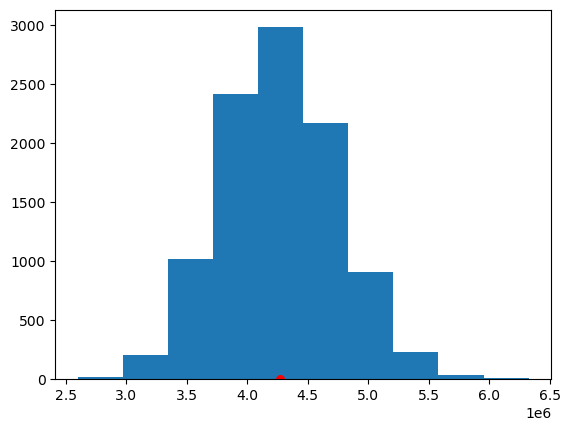

In [38]:
plt.hist(salary_avgs_list)
full_data_salary_avg = avg_salary
plt.scatter(full_data_salary_avg, 0, color='red', s=30, zorder=2)

plt.show()